In [12]:
import pandas as pd

train = pd.read_csv("../data/processed/processed_train.csv")
train.head()

,engine_id,cycle,op1,op2,op3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


## Feature Engineering (Time Series Signals)

We will create:
1. rolling_mean_sensor_X
2. rolling_std_sensor_X
3. sensor_X_delta
using windowed statistics per engine.

#### Step1: Identifying sensor columns

In [13]:
sensor_cols = [col for col in train.columns if "sensor" in col]
sensor_cols

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

#### Step2: Create Rolling Mean (Last 5 Cycles)

In [14]:
for sensor in sensor_cols:
    train[f'{sensor}_rolling_mean'] = (
        train.groupby('engine_id')[sensor]
        .rolling(window=5)
        .mean()
        .reset_index(level=0, drop=True)
    )

#### Step3: Create Rolling Standard Deviation
This captures sensor instability before failure

In [15]:
for sensor in sensor_cols:
    train[f'{sensor}_rolling_std'] = (
        train.groupby('engine_id')[sensor]
        .rolling(window=5)
        .std()
        .reset_index(level=0, drop=True)
    )

#### Step4: Create Sensor Change (Delta)
This captures rate of degradation

In [16]:
for sensor in sensor_cols:
    train[f'{sensor}_delta'] = (
        train.groupby('engine_id')[sensor]
        .diff()
    )

#### Step5: Handle NaN Values
Rolling windows create NaNs in early cycles.

In [17]:
train = train.fillna(0)

In [18]:
train.shape

(20631, 66)

### What happend above?
Transformed raw sensor data into predictive signals.
Instead of:

***sensor_11 = 540***

the model now sees:

***sensor_11 rolling trend***

**sensor volatility**

**sensor change rate**

## ML Model

#### Step1: Preparing Features and Target
Removing columns that the model should not learn from i.e., **engine_id -> identifier** & **cycle -> time index**

In [19]:
X = train.drop(columns=['engine_id', 'cycle', 'RUL'])
y = train['RUL']

#### Step2: Train/Test Split
Even though the dataset has a seperate test set, for now we create a validation split.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#### Step3: Train Random Forest Model
Random Forest works very well for tablular sensor data

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15, 
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

#### Step4: Make Predictions

In [22]:
y_pred = model.predict(X_val)

#### Step5: Evaluate Model Performance
For predictive maintenence, the common metrices are:
1. MAE (Mean Absolute Error)
2. RMSE (Root Mean Squared Error)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"Validation MAE: {mae:.2f}")
print(f"Validation RMSE: {rmse:.2f}")

Validation MAE: 11.12
Validation RMSE: 16.00


#### Step6: Visualizing Predictions

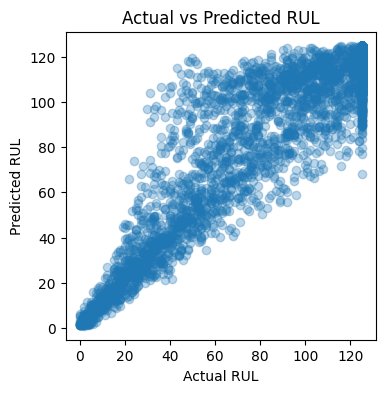

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

### WHAT IS THIS?
It is a working predictive maintenance model that:

**--> Uses time-series engineered features**

**--> Predicts remaining useful life**

**--> Uses ensemble ML methods**

So now, the black-box model (*It's a deep neural network model which is basically used to obtain high accuracy and precision and also helps in handling large and complex datasets.*)

But this model is not transparent which makes it harder to trust in sensitive domains like medicine, finance, law, etc. where stakeholders need to understand *why* a decision was made.

So, to answer *which sensors indicate failure?*

I have to analyze feature importance.

## Extracting Feature Importance

In [25]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance.head(10)

,feature,importance
20,sensor_4_rolling_mean,0.612514
25,sensor_11_rolling_mean,0.121396
24,sensor_9_rolling_mean,0.094819
28,sensor_14_rolling_mean,0.014702
29,sensor_15_rolling_mean,0.013790
22,sensor_7_rolling_mean,0.010451
26,sensor_12_rolling_mean,0.009401
18,sensor_2_rolling_mean,0.006327
19,sensor_3_rolling_mean,0.005885
31,sensor_20_rolling_mean,0.005270


#### Step2: Visualizing Important Sensors

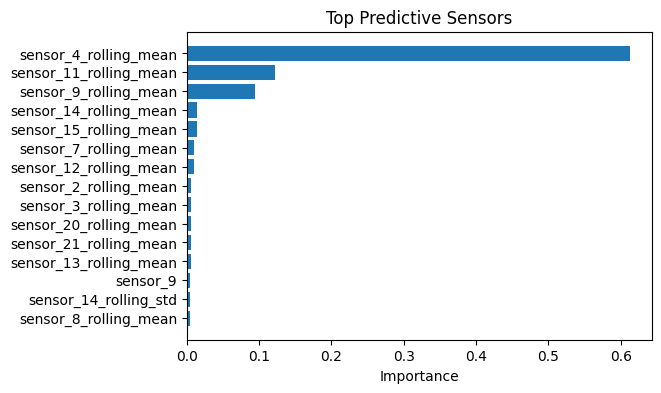

In [26]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(6,4))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Predictive Sensors")
plt.xlabel("Importance")
plt.show()

Since, *sensor_4_rolling_mean* dominating at 0.61.

So, 
**1. Sensor 4 is strongly correlates with engine degradation.**

**2. Or the model is relying heavily on it.**

To confirm this, let's visualize sensor 4 further.

#### Step3: Analyzing sensor_4 degradation pattern

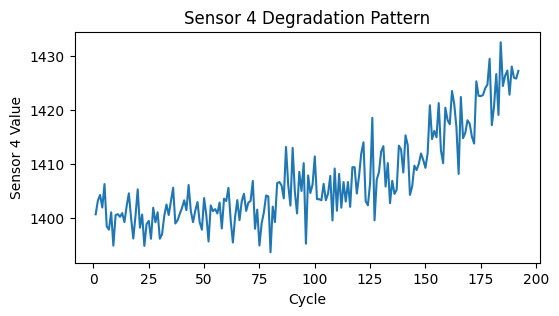

In [27]:
engine = train[train['engine_id'] == 1]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(engine['cycle'], engine['sensor_4'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 4 Value")
plt.title("Sensor 4 Degradation Pattern")
plt.show()

Converting this value into classification problem so the project turns into:

**Predictive Maintenence + Failure Risk Prediction System.**

#### Step1: Create Risk Categories

In [28]:
def categorize_risk(rul):
    if rul > 80:
        return "Low"
    elif rul > 30:
        return "Medium"
    else:
        return "High"

train['risk_level'] = train['RUL'].apply(categorize_risk)

Checking distribution:

In [29]:
train['risk_level'].value_counts()

risk_level
Low       12531
Medium     5000
High       3100
Name: count, dtype: int64

#### Step2: Prepare Classification Data

In [30]:
X_cls = train.drop(columns=['engine_id', 'cycle', 'RUL', 'risk_level'])
y_cls = train['risk_level']

#### Step3: Train Classifier

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

clf.fit(X_train_c, y_train_c)

RandomForestClassifier(max_depth=15, random_state=42)

#### Step4: Evaluate Classification

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_c = clf.predict(X_val_c)

print(classification_report(y_val_c, y_pred_c))

              precision    recall  f1-score   support

        High       0.92      0.85      0.88       584
         Low       0.88      0.96      0.92      2563
      Medium       0.77      0.62      0.69       980

    accuracy                           0.87      4127
   macro avg       0.86      0.81      0.83      4127
weighted avg       0.86      0.87      0.86      4127



### Implementing SHAP (SHapley Additive exPlanations)
When a model makes a prediction, SHAP calculates how much each feature contributed to that prediction.

##### Step1: Model Training with Engineered Features

In [33]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

##### Step2: Importing shap and creating Explainer
Since the model is using RandomForestRegression, so TreeExplainer works best for it

In [34]:
import shap

explainer = shap.TreeExplainer(model)

c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Step3: Calculate shap values
Using Sample values from dataset due to it's large size

In [35]:
X_sample = X_train.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

##### Step4: Global Feature Importance Plot
This will create a visualization showing: *Most influential features affecting RUL prediction*

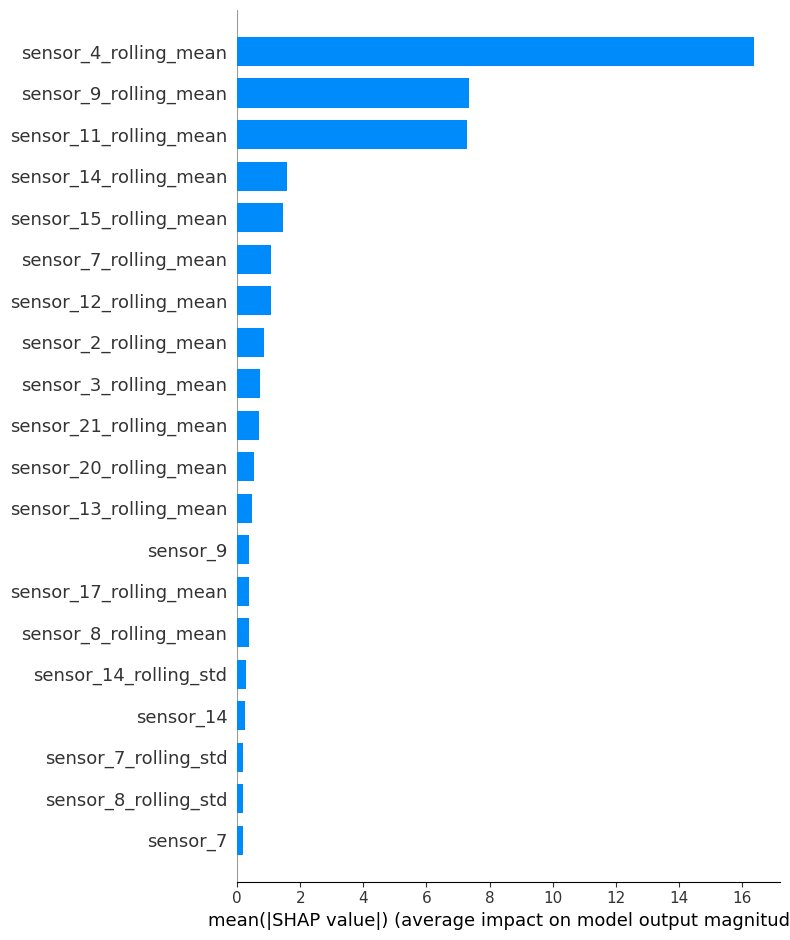

In [44]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

This tells engineers which sensors drive failure predictions.

### SAVING THE MODELS

In [45]:
import joblib

joblib.dump(model, "../models/rul_model.pkl")
joblib.dump(clf, "../models/risk_model.pkl")

print("Models saved successfully")

Models saved successfully


### SAVING ENGINEERED TRAIN DATA

In [46]:
train.to_csv("../data/processed/engineered_train.csv", index=False)